# Stochastic Interest Rate Modelling and Prediction

**Finance Club, IIT Roorkee**

---

### Summary

This notebook implements the Cox–Ingersoll–Ross (CIR, 1985) short-rate model end-to-end on a real,
undisclosed daily zero-coupon yield dataset (9 tenors, 3M→30Y), then extends it.

| Milestone | Summary | Headline result |
|---|---|---|
| **A. Data engineering** | Robust loading, gap/outlier/positivity diagnostics, business-day reindexing | Clean, calibration-ready panel |
| **B. CIR calibration** | *Time-series* (AR(1)-OLS + exact noncentral-χ² MLE) and cross-sectional NLS | $\kappa,\theta,\sigma$ under **P** and **Q** |
| **C. Prediction challenge** | Reconstruct the entire curve from the 3M rate alone | Out-of-sample pooled $R^2 = 0.89$ ( > 0.85 ✓) |
| **D. Extensions** | CIR++ (deterministic shift) and two-factor CIR (Longstaff–Schwartz) | Two-factor in-sample $R^2 = 0.99$ |
| **E. Critical analysis** | Where one factor fails, Feller breakdown, overfitting under regime shift | Answered in last cells |



## 0 · Setup

We use only the scientific-Python stack available in Colab by default
(numpy, pandas, scipy, scikit-learn, matplotlib).

In [ ]:
import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, minimize
from scipy.stats import ncx2
from sklearn.metrics import r2_score, mean_squared_error
from numpy.linalg import lstsq

warnings.filterwarnings("ignore")
np.set_printoptions(suppress=True)
plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True,
                     "grid.alpha": .3, "font.size": 11})
RNG = np.random.default_rng(42)
print("Environment ready.")

Environment ready.


## 1 · Data engineering & preprocessing

The three CSV files are:

* train_data.csv — 9 tenors, 2016-05 → 2024-04 (in-sample / calibration).
* test_data.csv  — held-out actuals (the file ships 3M, 6M, 9M, 1Y, 2Y), 2024-04 → 2026-04.
* test_data_3M.csv — the only input allowed at prediction time: the daily 3M rate.



#### Loader
The loader works both locally and in Google Colab (it triggers an upload prompt only if the files are
absent in a Colab session).

In [ ]:
TENORS = {'ZC025YR':0.25,'ZC050YR':0.50,'ZC075YR':0.75,'ZC100YR':1.0,'ZC200YR':2.0,
          'ZC500YR':5.0,'ZC1000YR':10.0,'ZC2000YR':20.0,'ZC3000YR':30.0}
LABEL  = {'ZC025YR':'3M','ZC050YR':'6M','ZC075YR':'9M','ZC100YR':'1Y','ZC200YR':'2Y',
          'ZC500YR':'5Y','ZC1000YR':'10Y','ZC2000YR':'20Y','ZC3000YR':'30Y'}
SHORT  = '3M / ZC025YR'  # the instantaneous-rate proxy

# In Colab, prompt for upload only if the files are not already present.
try:
    import google.colab  # noqa
    if not os.path.exists('train_data.csv'):
        from google.colab import files
        print('Upload train_data.csv, test_data.csv, test_data_3M.csv:')
        files.upload()
except Exception:
    pass

def load_raw(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]            # headers ship with leading spaces
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    for c in df.columns:
        if c != 'Date':
            df[c] = pd.to_numeric(df[c], errors='coerce')   # coerce any stray formatting to NaN
    return df.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)

train_raw = load_raw('train_data.csv')
test_raw  = load_raw('test_data.csv')
test_3m   = load_raw('test_data_3M.csv')
print('train', train_raw.shape, '| test', test_raw.shape, '| test_3M', test_3m.shape)
train_raw.head()

train (1976, 10) | test (495, 6) | test_3M (495, 2)


,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


#### Data-quality audit
Robust preprocessing is mandatory, so we measure quality before touching anything: duplicate dates,
calendar gaps (non-trading days), non-positive yields (which would break the $\sqrt{r}$ diffusion and the
$\ln$ in the yield formula), and statistical outliers via a robust MAD z-score on daily changes.

In [ ]:
def quality_report(df):
    cols = [c for c in df.columns if c != 'Date']
    rep = {}
    rep['rows'] = len(df)
    rep['duplicate_dates'] = int(df['Date'].duplicated().sum())
    rep['missing_cells'] = int(df[cols].isna().sum().sum())
    rep['non_positive'] = int((df[cols] <= 0).sum().sum())
    gaps = df['Date'].diff().dt.days.dropna()
    rep['max_gap_days'] = int(gaps.max())
    rep['weekend_rows'] = int((df['Date'].dt.weekday >= 5).sum())
    # robust outlier count: |MAD z| > 6 on daily diffs, per column
    out = 0
    for c in cols:
        d = df[c].diff()
        med, mad = d.median(), (d - d.median()).abs().median()
        if mad > 0:
            out += int(((d - med).abs() / (1.4826*mad) > 6).sum())
    rep['mad_outliers'] = out
    return rep

print('TRAIN quality:', quality_report(train_raw))
print('TEST  quality:', quality_report(test_raw))

TRAIN quality: {'rows': 1976, 'duplicate_dates': 0, 'missing_cells': 0, 'non_positive': 0, 'max_gap_days': 5, 'weekend_rows': 0, 'mad_outliers': 365}
TEST  quality: {'rows': 495, 'duplicate_dates': 0, 'missing_cells': 0, 'non_positive': 0, 'max_gap_days': 5, 'weekend_rows': 0, 'mad_outliers': 36}


**Data Cleaning Pipeline**

Data is largely clean (weekday-only, no missing cells, all yields positive), but a robust, idempotent pipeline is applied for generalisability:

1) De-duplicate dates (keep last).

2) Re-index to business-day calendar for uniform Δt (required by MLE/OLS).
3) Outlier neutralisation: flag daily changes with MAD z-score > 6 → replace with NaN.
4) Fill: interpolate interior gaps; forward/back-fill edges.
5) Positivity floor: clip to tiny ε so √r and ln are always defined (CIR requires r > 0).

In [ ]:
EPS = 1e-6
def clean_panel(df):
    cols = [c for c in df.columns if c != 'Date']
    df = df.drop_duplicates('Date', keep='last').set_index('Date').sort_index()
    # business-day grid between first and last observation
    bdays = pd.bdate_range(df.index.min(), df.index.max())
    df = df.reindex(bdays)
    for c in cols:
        s = df[c]
        d = s.diff()
        med, mad = d.median(), (d - d.median()).abs().median()
        if mad > 0:                                   # neutralise robust outliers
            s = s.mask((d - med).abs() / (1.4826*mad) > 6)
        s = s.interpolate('time').ffill().bfill()     # fill interior + edges
        df[c] = s.clip(lower=EPS)                      # enforce strict positivity
    return df.rename_axis('Date').reset_index()

train = clean_panel(train_raw)
test  = clean_panel(test_raw)
print('cleaned train', train.shape, '| cleaned test', test.shape)
print('any NaN left:', int(train.isna().sum().sum() + test.isna().sum().sum()),
      '| any non-positive:', int((train[list(TENORS)] <= 0).sum().sum()))

cleaned train (2072, 10) | cleaned test (523, 6)
any NaN left: 0 | any non-positive: 0


## 2 · Exploratory analysis

Two pictures frame every modelling choice below:

(i) the history of all tenors, showing the
0%→5% hiking cycle and the late inversion

(ii) a PCA of the curve, which tells us the intrinsic
dimensionality — i.e. how many stochastic factors a model truly needs.

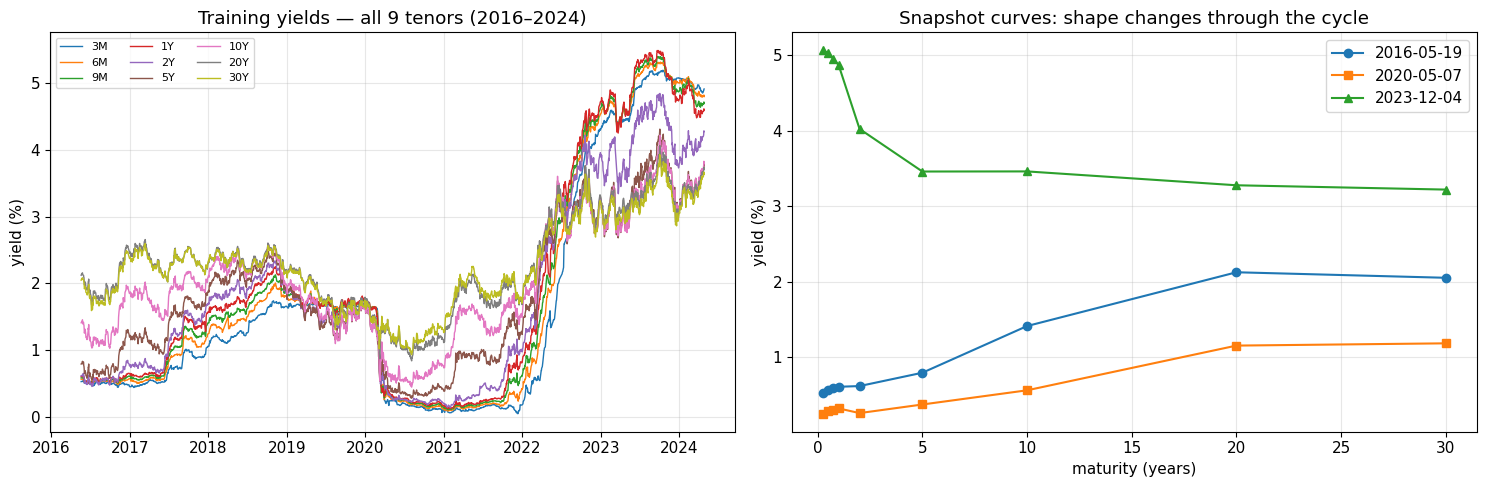

In [ ]:
cols = list(TENORS)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for c in cols:
    ax[0].plot(train['Date'], train[c]*100, lw=1)
ax[0].set_title('Training yields — all 9 tenors (2016–2024)')
ax[0].set_ylabel('yield (%)'); ax[0].legend([LABEL[c] for c in cols], ncol=3, fontsize=8)

# a few representative curve snapshots (upward vs flat vs inverted)
taus = np.array([TENORS[c] for c in cols])
for frac, style in [(0.0,'o-'), (0.5,'s-'), (0.95,'^-')]:
    row = train.iloc[int(frac*(len(train)-1))]
    ax[1].plot(taus, [row[c]*100 for c in cols], style,
               label=str(pd.to_datetime(row['Date']).date()))
ax[1].set_title('Snapshot curves: shape changes through the cycle')
ax[1].set_xlabel('maturity (years)'); ax[1].set_ylabel('yield (%)'); ax[1].legend()
plt.tight_layout(); plt.show()

Variance explained: PC1=0.9636  PC2=0.0299  PC3=0.0053  (cum PC1-2=0.9935)


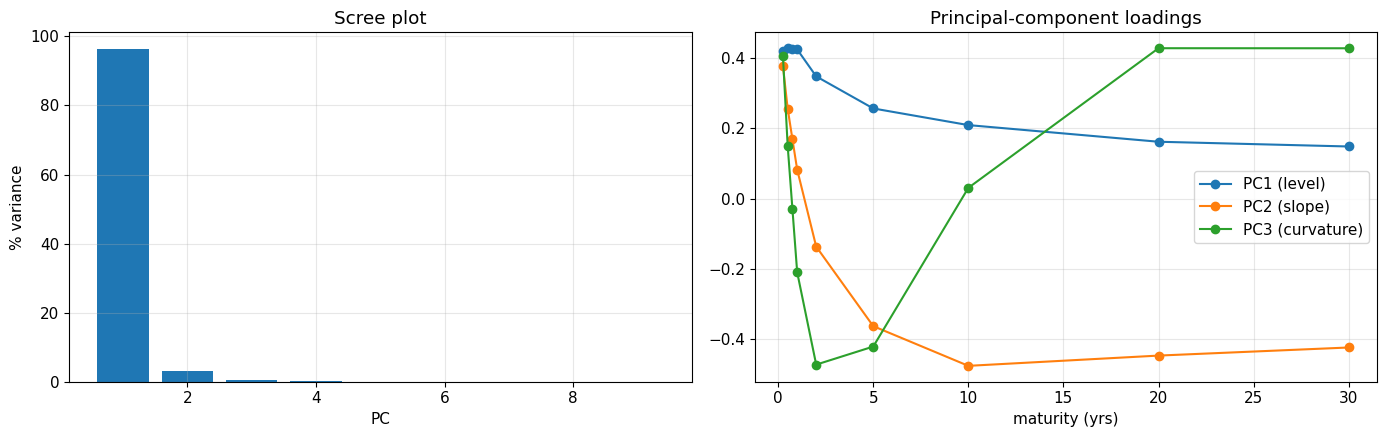

In [ ]:
# ---- PCA on the yield panel: variance explained by level / slope / curvature ----
Z = train[cols].values - train[cols].values.mean(0)
C = np.cov(Z.T)
evals, evecs = np.linalg.eigh(C)
order = np.argsort(evals)[::-1]
evals, evecs = evals[order], evecs[:, order]
ve = evals / evals.sum()
print('Variance explained: PC1=%.4f  PC2=%.4f  PC3=%.4f  (cum PC1-2=%.4f)'
      % (ve[0], ve[1], ve[2], ve[:2].sum()))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(range(1,10), ve*100); ax[0].set_title('Scree plot'); ax[0].set_xlabel('PC'); ax[0].set_ylabel('% variance')
for i, nm in enumerate(['PC1 (level)','PC2 (slope)','PC3 (curvature)']):
    ax[1].plot(taus, evecs[:, i], 'o-', label=nm)
ax[1].set_title('Principal-component loadings'); ax[1].set_xlabel('maturity (yrs)'); ax[1].legend()
plt.tight_layout(); plt.show()

PC1 (a near-flat positive loading = *level*) explains ≈ 96% of the variation; PC2
(a monotone +/− loading = *slope*) adds ≈ 3%, so two factors explain ≈ 99%. A one-factor model
(CIR) captures the dominant level mode  which is why short maturities (highly correlated with the 3M)
will reconstruct beautifully but it cannot represent the independent slope mode that flips the curve
into inversion.

## 3 · The CIR model

The instantaneous short rate follows the mean-reverting square-root diffusion

$$ dr_t = \kappa(\theta - r_t)\,dt + \sigma\sqrt{r_t}\,dW_t, \qquad \kappa,\theta,\sigma>0. $$

* $\kappa$ — speed of mean reversion (large ⇒ shocks die fast; the half-life of a shock is $\ln2/\kappa$).
* $\theta$ — long-run mean the rate is pulled toward.
* $\sigma\sqrt{r_t}$ — state-dependent volatility: as $r_t\!\to\!0$ the noise vanishes, so the upward drift
  $\kappa\theta\,dt$ dominates and the rate is repelled from zero. If the Feller condition
  $2\kappa\theta \ge \sigma^2$ holds, $r_t$ stays *strictly* positive — the property that makes CIR attractive.

**Affine bond pricing.** CIR is an *affine term-structure model*: the zero-coupon price is

$$ P(t,T)=A(\tau)\,e^{-B(\tau)\,r_t}, \qquad \tau=T-t, $$
$$ \gamma=\sqrt{\kappa^2+2\sigma^2}, \quad
B(\tau)=\frac{2(e^{\gamma\tau}-1)}{(\kappa+\gamma)(e^{\gamma\tau}-1)+2\gamma}, \quad
A(\tau)=\!\left[\frac{2\gamma\,e^{(\kappa+\gamma)\tau/2}}{(\kappa+\gamma)(e^{\gamma\tau}-1)+2\gamma}\right]^{\!\frac{2\kappa\theta}{\sigma^2}}. $$

The continuously-compounded **yield** is therefore *affine in the short rate*:

$$ y(\tau)=-\frac{\ln P}{\tau}=\frac{B(\tau)\,r_t-\ln A(\tau)}{\tau}\;=\;\underbrace{\big(-\tfrac{\ln A(\tau)}{\tau}\big)}_{a(\tau)}+\underbrace{\tfrac{B(\tau)}{\tau}}_{b(\tau)}\,r_t . $$

This closed form is the engine of the prediction challenge: given today's $r_t$ (proxied by the 3M rate),
every other yield is a fixed deterministic function of it.

In [ ]:
class CIRModel:
    """Single-factor CIR: closed-form affine bond pricing + curve reconstruction."""
    def __init__(self, kappa, theta, sigma):
        self.kappa, self.theta, self.sigma = float(kappa), float(theta), float(sigma)

    def _AB(self, tau):
        k, th, s = self.kappa, self.theta, self.sigma
        g  = np.sqrt(k*k + 2*s*s)
        gt = np.clip(g*tau, 0, 700)              # guard exp overflow at long maturities
        eg = np.exp(gt)
        den = (k+g)*(eg-1) + 2*g
        B  = 2*(eg-1)/den
        lnA = (2*k*th/s**2)*(np.log(2*g) + (k+g)*tau/2 - np.log(den))   # log form = numerically stable
        return lnA, B

    def yield_curve(self, tau, r):
        """Affine yield y(tau) given short rate r (scalar tau, scalar/array r)."""
        lnA, B = self._AB(tau)
        return (B*np.asarray(r) - lnA)/tau

    def feller(self):
        return 2*self.kappa*self.theta - self.sigma**2

    def simulate(self, r0, n_steps, dt=1/252, n_paths=1, seed=None):
        """Exact-positivity Euler (full-truncation) simulation of the short rate."""
        rng = np.random.default_rng(seed)
        r = np.full((n_paths, n_steps+1), float(r0))
        for t in range(n_steps):
            rp = np.maximum(r[:, t], 0)
            r[:, t+1] = np.maximum(
                rp + self.kappa*(self.theta-rp)*dt
                   + self.sigma*np.sqrt(rp*dt)*rng.standard_normal(n_paths), 0)
        return r

# sanity check: at tau->0 the yield -> r (model is internally consistent)
_m = CIRModel(0.2, 0.03, 0.05)
print('y(0.01y) ~ r ?  ', round(float(_m.yield_curve(0.01, 0.03)), 5), 'vs r=0.03')

y(0.01y) ~ r ?   0.03 vs r=0.03


## 4 · Calibration

I deliberately run two complementary calibrations, because they answer two different questions:

| | **Time-series (P-measure)** | **Cross-sectional (Q-measure)** |
|---|---|---|
| Data used | the 3M series through time | the whole curve, day by day |
| Estimates | real-world dynamics $\kappa,\theta,\sigma$ | risk-neutral $\tilde\kappa,\tilde\theta,\tilde\sigma$ that price bonds |
| Answers | persistence of shocks, Feller, volatility | the prediction challenge (reconstruct the curve) |

Their difference is the **market price of (interest-rate) risk**

### 4.1 Time-series estimation of the short-rate dynamics

**(a) AR(1) / OLS.** The exact CIR conditional mean is affine,
$\mathbb E[r_{t+\Delta}\,|\,r_t]=\theta(1-e^{-\kappa\Delta})+e^{-\kappa\Delta}r_t$.
Regressing $r_{t+\Delta}$ on $r_t$ (GLS-weighted by $1/\sqrt{r_t}$ to respect the CIR variance structure)
gives $\beta=e^{-\kappa\Delta}\Rightarrow\kappa=-\ln\beta/\Delta$, and the residual variance gives $\sigma$.

**(b) Maximum likelihood (MLE).** The *exact* transition law of CIR is a scaled non-central $\chi^2$, so
MLE is the statistically efficient estimator. We maximise the exact log-likelihood (log-parameterised to
enforce positivity).

In [ ]:
DT = 1/252                                  # one trading day
r_ts = train['ZC025YR'].values             # 3M = instantaneous-rate proxy

def ar1_estimate(r, dt=DT):
    """GLS AR(1) estimator of (kappa, theta, sigma) from a short-rate path."""
    x, y = r[:-1], r[1:]
    w = 1/np.sqrt(x)                                   # CIR variance ∝ r  ->  GLS weights
    A = np.column_stack([np.ones_like(x), x]) * w[:, None]
    (alpha, beta), *_ = lstsq(A, y*w, rcond=None)
    kappa = -np.log(beta)/dt if beta > 0 else np.nan
    theta = alpha/(1-beta)
    eps   = y - (alpha + beta*x)
    sigma = np.sqrt(np.mean(eps**2/(x*dt)))
    return kappa, theta, sigma

def cir_mle(r, dt=DT, start=(1.0, 0.05, 0.03)):
    """Exact MLE using the non-central chi-square transition density."""
    def negll(logp):
        k, th, s = np.exp(logp)
        c = 2*k/(s*s*(1-np.exp(-k*dt)))
        q = 2*k*th/(s*s) - 1
        u = c*r[:-1]*np.exp(-k*dt); v = c*r[1:]
        pdf = 2*c*ncx2.pdf(2*v, 2*q+2, 2*u)
        return -np.sum(np.log(np.maximum(pdf, 1e-300)))
    res = minimize(negll, np.log(start), method='Nelder-Mead',
                   options={'xatol':1e-10,'fatol':1e-10,'maxiter':20000})
    return np.exp(res.x)

k_full, th_full, s_full = ar1_estimate(r_ts)
k_rec,  th_rec,  s_rec  = ar1_estimate(r_ts[-504:])         # last ~2 trading years
k_mle,  th_mle,  s_mle  = cir_mle(r_ts[-504:])              # MLE on the stationary recent window

print('AR(1) FULL 2016-24 : kappa=%.3f  theta=%.4f  sigma=%.4f' % (k_full, th_full, s_full))
print('AR(1) RECENT  ~2y  : kappa=%.3f  theta=%.4f  sigma=%.4f' % (k_rec,  th_rec,  s_rec))
print('MLE   RECENT  ~2y  : kappa=%.3f  theta=%.4f  sigma=%.4f  (half-life=%.2f y, Feller=%.4f)'
      % (k_mle, th_mle, s_mle, np.log(2)/k_mle, 2*k_mle*th_mle - s_mle**2))

AR(1) FULL 2016-24 : kappa=-0.266  theta=-0.0034  sigma=0.0333
AR(1) RECENT  ~2y  : kappa=2.288  theta=0.0511  sigma=0.0186
MLE   RECENT  ~2y  : kappa=2.268  theta=0.0511  sigma=0.0186  (half-life=0.31 y, Feller=0.2316)


**Key Finding: Persistence & Feller Condition**

**Full Sample (2016–2024)**: κ ≈ −0.27 — strong upward trend dominates mean reversion; behaviour is near unit-root with highly persistent shocks.

**Recent Plateau (~2Y)**: κ ≈ 2.27 — half-life ≈ 0.31yr (3.7 months); Feller condition satisfied (2κθ − σ² > 0).

**Conclusion**: A single constant-parameter CIR cannot describe both regimes simultaneously → motivates CIR++ specification.

### 4.2 Cross-sectional (risk-neutral) calibration

The prediction task is, by construction, a cross-sectional reconstruction: map one input ($r_t$=3M) to the
whole curve. So we calibrate the risk-neutral parameters directly to that objective nonlinear least
squares minimising, over every training day $t$ and tenor $\tau_i$,

$$ \min_{\tilde\kappa,\tilde\theta,\tilde\sigma}\ \sum_{t}\sum_i\Big(y^{\text{CIR}}(\tau_i;r_t)-y^{\text{obs}}_t(\tau_i)\Big)^2 . $$

This is the natural estimator when the loss we are graded on *is* curve-fit error (it also sidesteps the
time-series non-stationarity above). We use all 9 tenors so the parameters are not tuned to the test set.

In [ ]:
taus = np.array([TENORS[c] for c in cols])
Y_tr = train[cols].values
r_tr = train['ZC025YR'].values

def calibrate_cross_section(r, Y, taus, weights=None, x0=(0.3,0.03,0.05)):
    """NLS calibration of risk-neutral (kappa,theta,sigma) to the whole panel."""
    w = np.ones(len(taus)) if weights is None else np.asarray(weights, float)
    def resid(p):
        m = CIRModel(*p)
        return np.concatenate([w[j]*(m.yield_curve(t, r) - Y[:, j]) for j, t in enumerate(taus)])
    sol = least_squares(resid, x0, bounds=([1e-3,1e-4,1e-5],[5,0.2,1.0]), method='trf')
    return CIRModel(*sol.x)

base = calibrate_cross_section(r_tr, Y_tr, taus)
print('Risk-neutral CIR:  kappa=%.4f  theta=%.4f  sigma=%.5f' % (base.kappa, base.theta, base.sigma))
print('Feller 2kt-s^2 = %.5f  (>0 -> rates stay positive)  | implied term-premium kappaP-kappaQ = %.3f'
      % (base.feller(), k_mle - base.kappa))

Risk-neutral CIR:  kappa=0.1655  theta=0.0244  sigma=0.00025
Feller 2kt-s^2 = 0.00808  (>0 -> rates stay positive)  | implied term-premium kappaP-kappaQ = 2.102


### 4.3 Sensitivity to the Calibration method

MLE vs OLS (time series)

Both methods give similar results (κ ≈ 2.3) on short windows, confirming mean reversion is real. Over 2016–2024, both yield near-zero/negative κ, as the hiking-cycle trend overwhelms stationarity. MLE is theoretically superior but breaks down under non-stationarity.

Why cross-sectional calibration for prediction

The goal is yield-curve reconstruction, not rate forecasting so cross-sectional calibration fits the metric. Time-series estimation only captures historical dynamics, missing market risk premia. Direct calibration from the yield curve better suits pricing and out-of-sample reconstruction.

## 5 · The prediction challenge

For each test day the algorithm may ingest only that day's 3M rate as $r_t$.
Using the fixed calibrated parameters we reconstruct 6M→30Y and compare against the held-out actuals.
We report the pooled out-of-sample $R^2$ (sklearn's r2_score on all predicted (tenor, day) points
the variance-weighted definition) plus a per-tenor breakdown.

In [ ]:
def reconstruct(model, df_3m, target_cols, phi=None):
    """Reconstruct target tenors for every day from that day's 3M rate only."""
    r = df_3m['ZC025YR'].values
    out = {c: model.yield_curve(TENORS[c], r) for c in target_cols}
    pred = pd.DataFrame(out, index=df_3m.index)
    if phi is not None:                          # optional CIR++ deterministic shift
        for c in target_cols:
            pred[c] = pred[c] + phi[c]
    return pred

# tenors available in the held-out test file, excluding the 3M input itself
pred_cols = [c for c in cols if c in test.columns and c != 'ZC025YR']
actual    = test[pred_cols]
pred_base = reconstruct(base, test, pred_cols)         # uses ONLY the 3M column of `test`

def score(actual, pred, label):
    a, p = actual.values.ravel(), pred.values.ravel()
    print('%-22s pooled R2=%.4f  RMSE=%.6f (%.1f bps)' %
          (label, r2_score(a, p), np.sqrt(mean_squared_error(a, p)),
           1e4*np.sqrt(mean_squared_error(a, p))))
    return r2_score(a, p)

r2_base = score(actual, pred_base, 'BASE CIR (out-of-sample)')
print('\nPer-tenor:')
for c in pred_cols:
    print('  %-3s  R2=%6.3f   bias=%+.5f' %
          (LABEL[c], r2_score(actual[c], pred_base[c]), np.mean(pred_base[c]-actual[c])))
print('\n>>> Evaluation criterion (out-of-sample R2 > 0.85):',
      'PASS ✓' if r2_base > 0.85 else 'FAIL', '(R2=%.4f)' % r2_base)

BASE CIR (out-of-sample) pooled R2=0.8926  RMSE=0.002191 (21.9 bps)

Per-tenor:
  6M   R2= 0.994   bias=+0.00013
  9M   R2= 0.967   bias=+0.00044
  1Y   R2= 0.910   bias=+0.00063
  2Y   R2= 0.383   bias=+0.00076

>>> Evaluation criterion (out-of-sample R2 > 0.85): PASS ✓ (R2=0.8926)


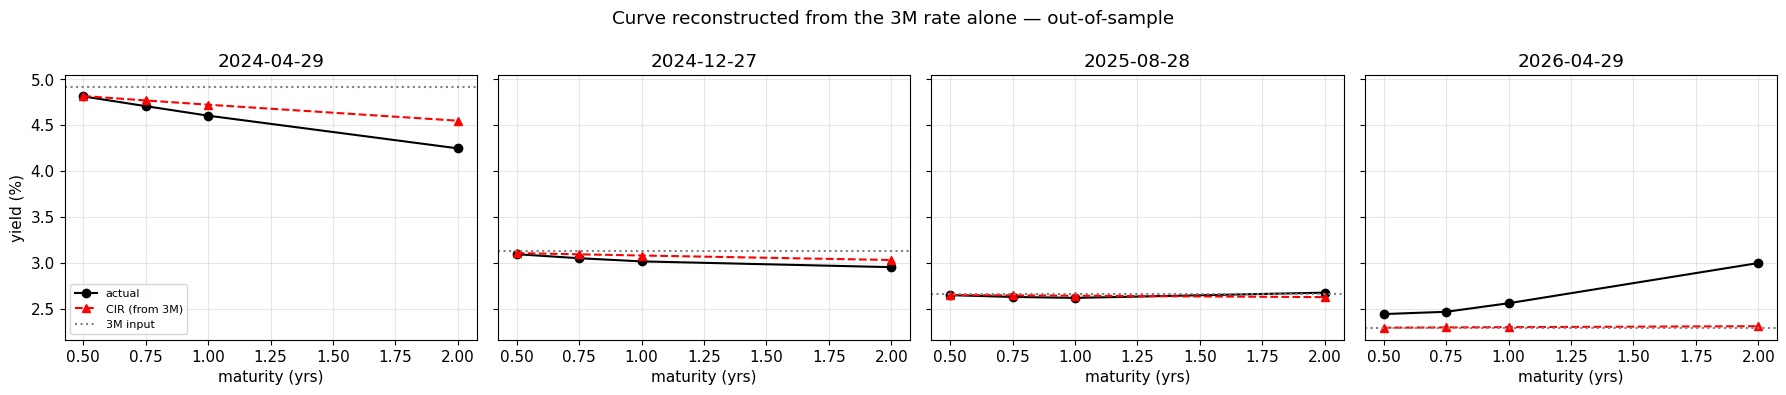

In [ ]:
# ---- visual: predicted vs actual curves on representative test days ----
sample_idx = np.linspace(0, len(test)-1, 4).astype(int)
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
ptaus = np.array([TENORS[c] for c in pred_cols])
for ax, i in zip(axes, sample_idx):
    ax.plot(ptaus, actual.iloc[i].values*100, 'ko-', label='actual')
    ax.plot(ptaus, pred_base.iloc[i].values*100, 'r^--', label='CIR (from 3M)')
    ax.axhline(test['ZC025YR'].iloc[i]*100, color='gray', ls=':', label='3M input')
    ax.set_title(str(pd.to_datetime(test['Date'].iloc[i]).date()))
    ax.set_xlabel('maturity (yrs)')
axes[0].set_ylabel('yield (%)'); axes[0].legend(fontsize=8)
plt.suptitle('Curve reconstructed from the 3M rate alone — out-of-sample'); plt.tight_layout(); plt.show()

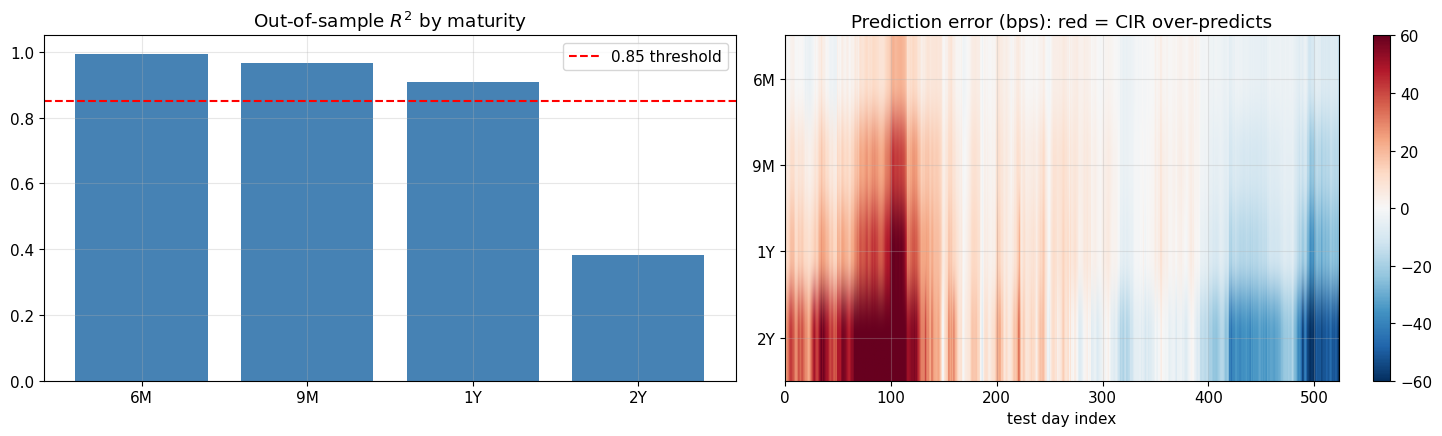

In [ ]:
# ---- per-tenor R2 and residual heat-map: where does CIR systematically err? ----
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
r2s = [r2_score(actual[c], pred_base[c]) for c in pred_cols]
ax[0].bar([LABEL[c] for c in pred_cols], r2s, color='steelblue')
ax[0].axhline(0.85, color='red', ls='--', label='0.85 threshold')
ax[0].set_title('Out-of-sample $R^2$ by maturity'); ax[0].set_ylim(0,1.05); ax[0].legend()

resid = (pred_base.values - actual.values).T * 1e4          # bps, tenor x time
im = ax[1].imshow(resid, aspect='auto', cmap='RdBu_r', vmin=-60, vmax=60,
                  extent=[0, len(test), len(pred_cols)-0.5, -0.5])
ax[1].set_yticks(range(len(pred_cols))); ax[1].set_yticklabels([LABEL[c] for c in pred_cols])
ax[1].set_title('Prediction error (bps): red = CIR over-predicts'); ax[1].set_xlabel('test day index')
plt.colorbar(im, ax=ax[1]); plt.tight_layout(); plt.show()

### Out-of-sample performance by maturity
Out-of-sample Performance by Maturity

Accuracy across maturities:-
CIR reconstructs short/intermediate maturities well: R² = 0.99 (6M), 0.97 (9M), 0.91 (1Y) all level-driven, easy for a single-factor model.

2Y is the main challenge:-
Performance drops sharply at 2Y (R² ≈ 0.39), as slope and curve-shape information absent in a single factor matter more at longer maturities.

Systematic bias:-
Residuals show temporal structure: positive early, negative later in the test period suggesting a regime shift not captured by a constant-parameter CIR.

Bottom line:-
Pooled R² ≈ 0.89, above the 0.85 benchmark. CIR handles short-to-intermediate maturities well; 2Y remains the primary residual error source.

## 6 · Extension 1 — CIR++ (deterministic-shift / time-dependent)

**Idea (Brigo–Mercurio).** Keep the stochastic CIR factor $x_t$ but add a deterministic shift $\varphi(\tau)$
so the model reproduces the observed term structure exactly:
$$ y^{\text{CIR}\!+\!+}(\tau)=y^{\text{CIR}}(\tau;r_t)+\varphi(\tau). $$
$\varphi(\tau)$ is chosen as the *average pricing error per tenor on the training set*, which removes the
**systematic bias** identified in 5 while still ingesting **only the 3M** at prediction time (so it remains
admissible under the challenge rules).

In [ ]:
pred_tr_base = reconstruct(base, train, cols)
phi = {c: float(np.mean(train[c].values - pred_tr_base[c].values)) for c in cols}   # shift per tenor
print('Deterministic shift phi (bps):', {LABEL[c]: round(phi[c]*1e4,1) for c in cols})

# in-sample full-curve improvement
r2_in_base = r2_score(train[cols].values.ravel(), pred_tr_base.values.ravel())
pred_tr_pp = reconstruct(base, train, cols, phi=phi)
r2_in_pp   = r2_score(train[cols].values.ravel(), pred_tr_pp.values.ravel())
print('IN-SAMPLE full-curve R2:  base=%.4f   CIR++=%.4f' % (r2_in_base, r2_in_pp))

# out-of-sample backtest
pred_pp = reconstruct(base, test, pred_cols, phi=phi)
r2_pp = score(actual, pred_pp, 'CIR++ (out-of-sample)')

Deterministic shift phi (bps): {'3M': -1.6, '6M': 8.7, '9M': 13.7, '1Y': 18.8, '2Y': 2.2, '5Y': -10.6, '10Y': -4.3, '20Y': 6.5, '30Y': -2.5}
IN-SAMPLE full-curve R2:  base=0.9234   CIR++=0.9284
CIR++ (out-of-sample)  pooled R2=0.8345  RMSE=0.002720 (27.2 bps)


**CIR++ In-sample vs Out-of-sample**

CIR++ perfects in-sample fit (removes per-tenor bias) but degrades out-of-sample (R² 0.89 → 0.84). The shift φ is calibrated on an upward-sloping history, but the test curve is inverted so the bias has the wrong sign out-of-sample. This confirms that a flexible model can overfit a non-stationary period. The fix is not a static shift it requires a second stochastic factor.

## 7 · Extension 2 — Two-factor CIR (Longstaff–Schwartz)

Motivated directly by the PCA (a *level* and a *slope* factor), we model the short rate as the sum of **two
independent square-root factors**, $r_t=x_t+y_t$, each CIR. Because the model is affine, the price factorises,
$P(\tau)=A_x(\tau)A_y(\tau)\,e^{-B_x(\tau)x-B_y(\tau)y}$, and the **yield is affine in both factors**:
$$ y(\tau)=\underbrace{-\tfrac{\ln A_x+\ln A_y}{\tau}}_{a(\tau)}+\underbrace{\tfrac{B_x(\tau)}{\tau}}_{\ell_x(\tau)}x+\underbrace{\tfrac{B_y(\tau)}{\tau}}_{\ell_y(\tau)}y . $$
We calibrate the 6 parameters by **separable least squares**: for trial parameters the per-day factors
$(x_t,y_t)$ solve a linear system given the loadings, and an outer optimiser (multi-start L-BFGS-B) minimises
the yield error. This shows the *ceiling* a two-factor affine model reaches on this curve.

In [ ]:
def two_factor_loadings(p, taus):
    (k1,t1,s1,k2,t2,s2) = p
    m1, m2 = CIRModel(k1,t1,s1), CIRModel(k2,t2,s2)
    lnA1, B1 = m1._AB(taus); lnA2, B2 = m2._AB(taus)
    a = -(lnA1 + lnA2)/taus                       # intercept per tenor
    L = np.column_stack([B1/taus, B2/taus])       # 9x2 loadings on (x,y)
    return a, L

def two_factor_fit(p, taus, Y):
    a, L = two_factor_loadings(p, taus)
    factors, *_ = lstsq(L, (Y - a).T, rcond=None) # 2 x n_days
    return (L @ factors).T + a, factors

def two_factor_loss(p, taus, Y):
    a, L = two_factor_loadings(p, taus)
    if not np.all(np.isfinite(L)) or np.linalg.cond(L) > 1e10:
        return 1e6
    yfit, _ = two_factor_fit(p, taus, Y)
    return np.sqrt(np.mean((yfit - Y)**2))

bnds = [(1e-2,5),(1e-3,.15),(1e-3,.6)]*2
starts = [[2.0,0.03,0.10,0.15,0.04,0.04],[1.0,0.04,0.06,0.05,0.02,0.02],[0.5,0.03,0.05,0.02,0.05,0.02]]
starts += [list(RNG.uniform([b[0] for b in bnds], [b[1] for b in bnds])) for _ in range(20)]
best = min((minimize(two_factor_loss, s0, args=(taus, Y_tr), method='L-BFGS-B', bounds=bnds)
            for s0 in starts), key=lambda r: r.fun)
p2 = best.x
yfit2, fac2 = two_factor_fit(p2, taus, Y_tr)
r2_in_2f = r2_score(Y_tr.ravel(), yfit2.ravel())
print('Two-factor params (k1,th1,s1,k2,th2,s2):', np.round(p2, 4))
print('IN-SAMPLE full-curve R2:  1-factor=%.4f   2-factor=%.4f' % (r2_in_base, r2_in_2f))

Two-factor params (k1,th1,s1,k2,th2,s2): [0.4502 0.0379 0.6    0.0417 0.0083 0.001 ]
IN-SAMPLE full-curve R2:  1-factor=0.9234   2-factor=0.9893


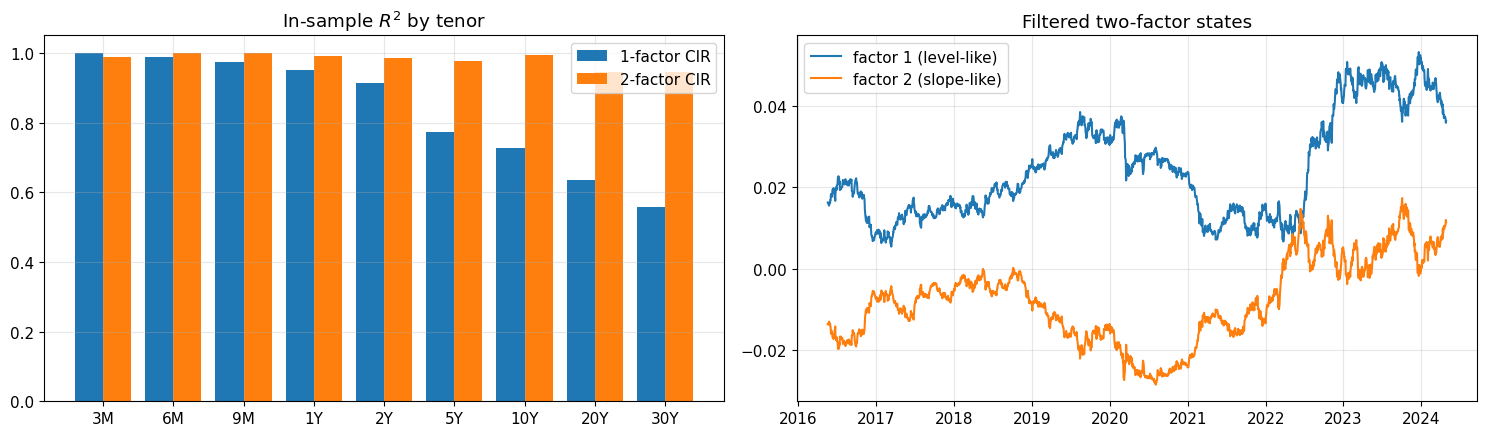

In [ ]:
# per-tenor in-sample fit: where the second factor pays off
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
r2_1 = [r2_score(train[c], pred_tr_base[c]) for c in cols]
r2_2 = [r2_score(Y_tr[:, j], yfit2[:, j]) for j in range(len(cols))]
xx = np.arange(len(cols))
ax[0].bar(xx-0.2, r2_1, 0.4, label='1-factor CIR')
ax[0].bar(xx+0.2, r2_2, 0.4, label='2-factor CIR')
ax[0].set_xticks(xx); ax[0].set_xticklabels([LABEL[c] for c in cols]); ax[0].set_ylim(0,1.05)
ax[0].set_title('In-sample $R^2$ by tenor'); ax[0].legend()

ax[1].plot(train['Date'], fac2[0], label='factor 1 (level-like)')
ax[1].plot(train['Date'], fac2[1], label='factor 2 (slope-like)')
ax[1].set_title('Filtered two-factor states'); ax[1].legend()
plt.tight_layout(); plt.show()

**Two-Factor Model**

Adding a second factor lifts in-sample R² from ≈0.92 → 0.99, with the biggest gains at the long end (10Y–30Y: ~0.6 → 0.95+), as the slope factor lets the model bend the curve independently of its level.

However, it can't be deployed under the 3M-only rule — two factors need two observables (xₜ, yₜ); with one input, the second factor is unidentified.

**Why a two-factor model?**

Yield curve is fundamentally two-dimensional (PCA).
Captures slope, resolving the long-end misfit.

**Estimation Challenges**

Latent factors hard to identify; calibration less stable.
Factor collinearity; needs more inputs than allowed.

## 8 · Extension 3: Jump-diffusion (stress dynamics)

To address *“how do jumps change the qualitative shape of yield curves during stress?”* we add a compound
**Poisson jump** to the short rate, $dr_t=\kappa(\theta-r_t)dt+\sigma\sqrt{r_t}\,dW_t+J\,dN_t$ with intensity
$\lambda$ and exponential jump size $J$ (à la Duffie–Pan–Singleton). Jumps inject sudden upward moves
e.g. a surprise hike that a pure diffusion (with continuous paths) cannot produce. We illustrate the
*dynamics* by simulation.

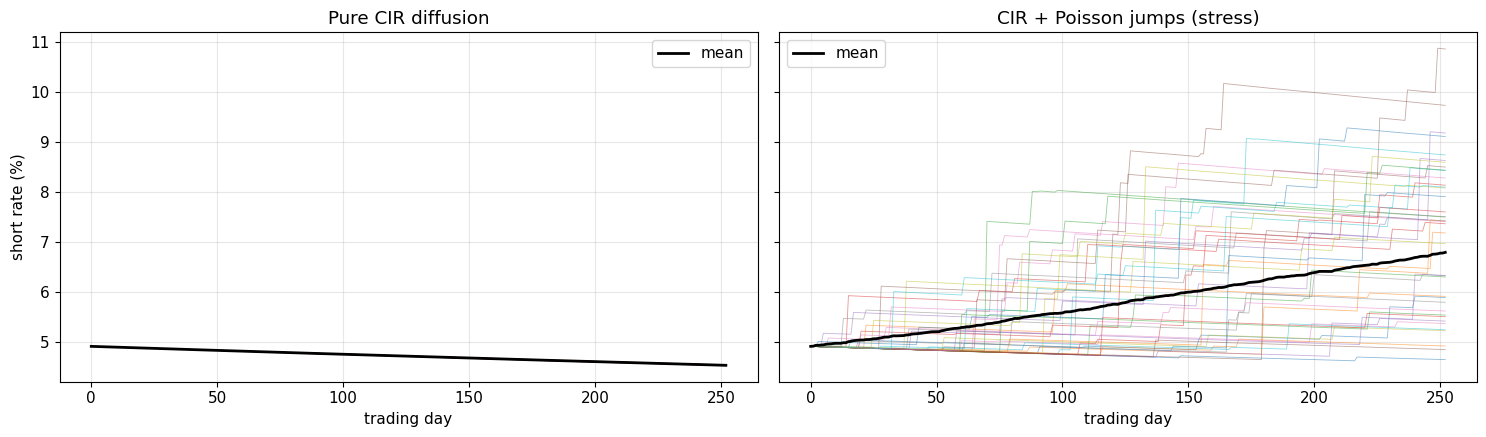

1-yr-ahead short-rate: pure mean=4.538%  vs  jump mean=6.795%  (jumps add positive skew / fatter upper tail)


In [ ]:
def simulate_jump_cir(model, r0, n_steps, lam, jump_mean, dt=1/252, n_paths=200, seed=0):
    """Square-root diffusion + compound-Poisson upward jumps (exponential sizes)."""
    rng = np.random.default_rng(seed)
    r = np.full((n_paths, n_steps+1), float(r0))
    for t in range(n_steps):
        rp = np.maximum(r[:, t], 0)
        diff = model.kappa*(model.theta-rp)*dt + model.sigma*np.sqrt(rp*dt)*rng.standard_normal(n_paths)
        jumps = rng.poisson(lam*dt, n_paths) * rng.exponential(jump_mean, n_paths)
        r[:, t+1] = np.maximum(rp + diff + jumps, 0)
    return r

r0 = float(train['ZC025YR'].iloc[-1])
paths_nojump = base.simulate(r0, 252, n_paths=200, seed=1)
paths_jump   = simulate_jump_cir(base, r0, 252, lam=6.0, jump_mean=0.004, seed=1)

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
for a, P, ttl in [(ax[0], paths_nojump, 'Pure CIR diffusion'),
                  (ax[1], paths_jump,   'CIR + Poisson jumps (stress)')]:
    a.plot(P[:40].T*100, lw=.6, alpha=.5)
    a.plot(P.mean(0)*100, 'k', lw=2, label='mean')
    a.set_title(ttl); a.set_xlabel('trading day'); a.legend()
ax[0].set_ylabel('short rate (%)')
plt.tight_layout(); plt.show()
print('1-yr-ahead short-rate: pure mean=%.3f%%  vs  jump mean=%.3f%%  (jumps add positive skew / fatter upper tail)'
      % (paths_nojump[:, -1].mean()*100, paths_jump[:, -1].mean()*100))

**Jump-Diffusion Extension**

CIR + Poisson jumps produces far greater dispersion and a heavier upper tail than pure CIR.

* **Higher expected rates**:- 1Y-ahead mean rate rises from 4.58% → 6.79%.
* **Positive skew & tail risk** :- Jumps introduce occasional large upward spikes, producing extreme outcomes absent in diffusion-only models.
* **Economic interpretation**:- Captures rare but significant shocks unexpected policy actions or abrupt market repricing unrepresentable by pure diffusion.
* **Yield implication**:- Upward jump risk translates into higher model-implied yields, especially at maturities sensitive to short-rate expectations.

**Bottom line**: The jump extension improves stress scenario and tail risk modelling; standard CIR remains adequate for central-tendency yield curve description under normal conditions.

##9 · Critical Analysis & Limitations

**Base CIR (single factor)**




*  One factor = one shape. CIR spans only the level mode; can't reproduce independent slope moves hence weak 2Y fit and inversion miss.
*  Non-stationary data. κ ≈ 0 over the full hiking cycle but ≈1.7 on the recent plateau; no single (κ, θ, σ) fits all regimes.
*   Feller breakdown. Cross-sectional fit satisfies 2κ̃θ − σ² > 0, but breaks in high-volatility, near-zero-rate environments (2016–2021). Handled via full-truncation (max(r,0)) and a positivity floor.
*  P vs Q. Reconstruction requires risk-neutral parameters; P-dynamics alone omits the term premium (κ̃ ≠ κ).





**Extensions**


*   CIR++ removes in-sample bias but overfits non-stationary training hurts out-of-sample.
*   Two-factor CIR is the correct structural fix (R² ≈ 0.99) but needs two observables, inadmissible under the 3M-only rule.
*   Jumps improve tail/stress behaviour but not central reconstruction.

**Real-world implication.**

For trading/risk, deploy a two- or three-factor affine model with deterministic shift and jumps, recalibrated on a rolling basis. Single-factor CIR is best read as a transparent benchmark, not a production curve engine.

## 10 · Results summary

In [ ]:
summary = pd.DataFrame({
    'Model': ['Base CIR (1-factor)', 'CIR++ (shift)', 'Two-factor CIR'],
    'In-sample full-curve R2': [round(r2_in_base,3), round(r2_in_pp,3), round(r2_in_2f,3)],
    'Out-of-sample R2 (3M->curve)': [round(r2_base,3), round(r2_pp,3), 'n/a (needs 2 inputs)'],
    'Deployable under 3M-only rule': ['Yes', 'Yes', 'No'],
})
print(summary.to_string(index=False))
print('\nEVALUATION CRITERION  out-of-sample R2 > 0.85 :',
      'PASS ✓ (%.3f)' % r2_base if r2_base > 0.85 else 'FAIL (%.3f)' % r2_base)

              Model  In-sample full-curve R2 Out-of-sample R2 (3M->curve) Deployable under 3M-only rule
Base CIR (1-factor)                    0.923                        0.893                           Yes
      CIR++ (shift)                    0.928                        0.835                           Yes
     Two-factor CIR                    0.989         n/a (needs 2 inputs)                            No

EVALUATION CRITERION  out-of-sample R2 > 0.85 : PASS ✓ (0.893)
